In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
ROOT = Path.cwd().resolve()
while ROOT.name != 'observatory_benchmark' and ROOT.parent != ROOT:
    ROOT = ROOT.parent

if ROOT.name != 'observatory_benchmark':
    raise RuntimeError('Could not locate the observatory_benchmark repository root from the current working directory.')

base_path = ROOT / 'PhysiCell' / 'results' / 'decay_study'
folders = ['size_5', 'size_10', 'size_20', 'size_40']
csv_filename = 'physicell_decay_plot_data.csv'


def load_physicell_csv(folder: str) -> pd.DataFrame:
    csv_path = base_path / folder / csv_filename
    frame = pd.read_csv(csv_path)
    required_columns = ['time_min', 'average_uM', 'center_uM', 'dx_um']
    missing_columns = [column for column in required_columns if column not in frame.columns]
    if missing_columns:
        raise ValueError(f'{csv_path} is missing required columns: {missing_columns}')

    frame = frame.sort_values('time_min').reset_index(drop=True)
    return frame

In [52]:

# analytical solution of average of whole box
dt_analytical = [ 0.,0.52631579,1.05263158,1.57894737,2.10526316,2.63157895
,3.15789474,3.68421053,4.21052632,4.73684211,5.26315789,5.78947368
,6.31578947,6.84210526,7.36842105,7.89473684,8.42105263,8.94736842
,9.47368421,10.]

dif_analytical = [10.,7.79217467,7.1711064, 6.96508102,6.89482579,6.87071343
,6.86242517,6.85957518,6.8585951, 6.85825806,6.85814215,6.85810229
,6.85808858,6.85808387,6.85808224,6.85808169,6.8580815, 6.85808143
,6.85808141,6.8580814 ]



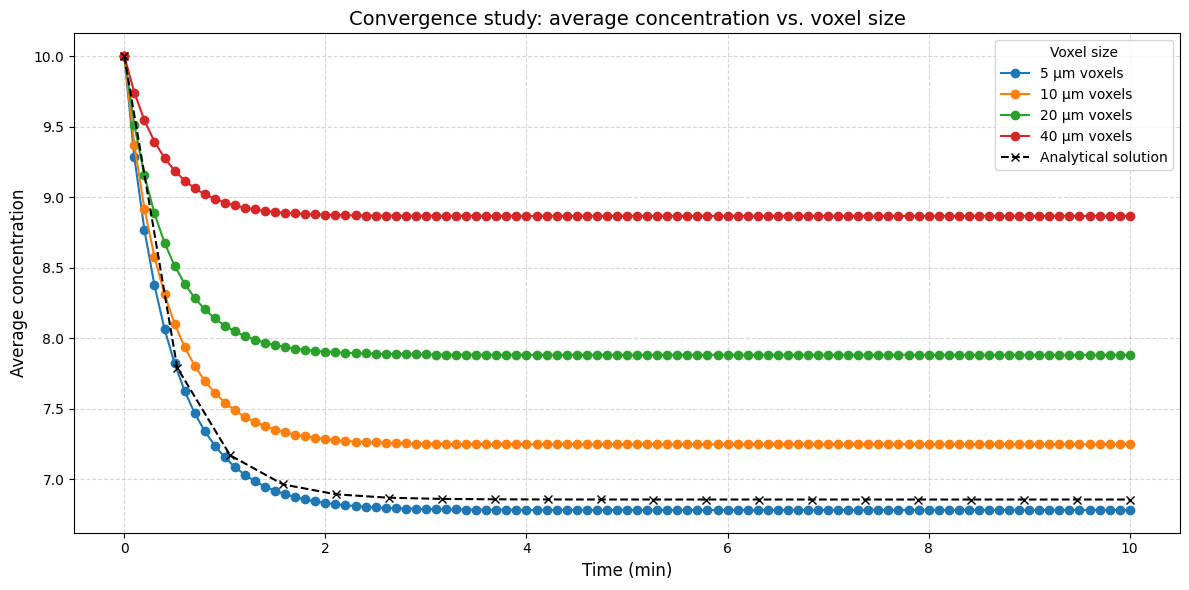

In [ ]:
# --- settings ---

# prepare full-range figure
fig, ax = plt.subplots(figsize=(12, 6))
global_max = 0.0
series_by_label = {}

for folder in folders:
    frame = load_physicell_csv(folder)
    dh = float(frame['dx_um'].iloc[0])
    times = frame['time_min'].to_numpy(dtype=float)
    mean = frame['average_uM'].to_numpy(dtype=float)

    label = f"{int(dh)} μm voxels"
    series = pd.Series(
        mean,
        index=pd.Index(times, name='Time (min)'),
        name=label,
    )
    series.plot(ax=ax, marker='o', linestyle='-', label=label)

    series_by_label[label] = series
    global_max = max(global_max, series.max())

ax.plot(dt_analytical, dif_analytical, label='Analytical solution', color='black', linestyle='--', marker='x')
ax.set_xlabel('Time (min)', fontsize=12)
ax.set_ylabel('Average concentration', fontsize=12)
ax.set_title('Convergence study: average concentration vs. voxel size', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Voxel size', loc='upper right')

plt.tight_layout()
plt.show()

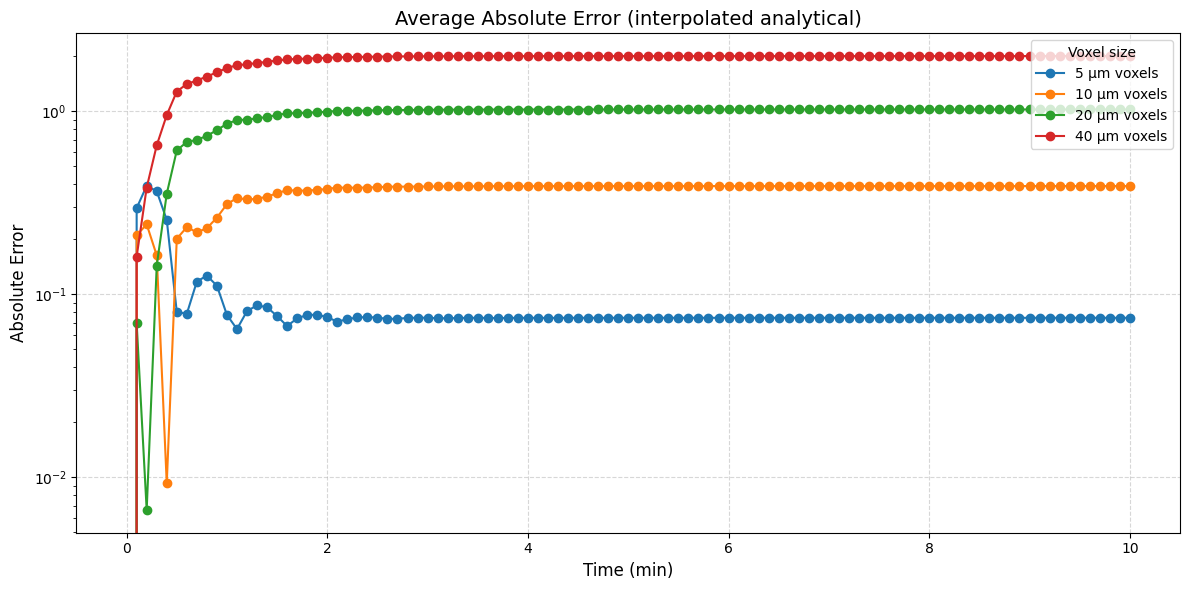

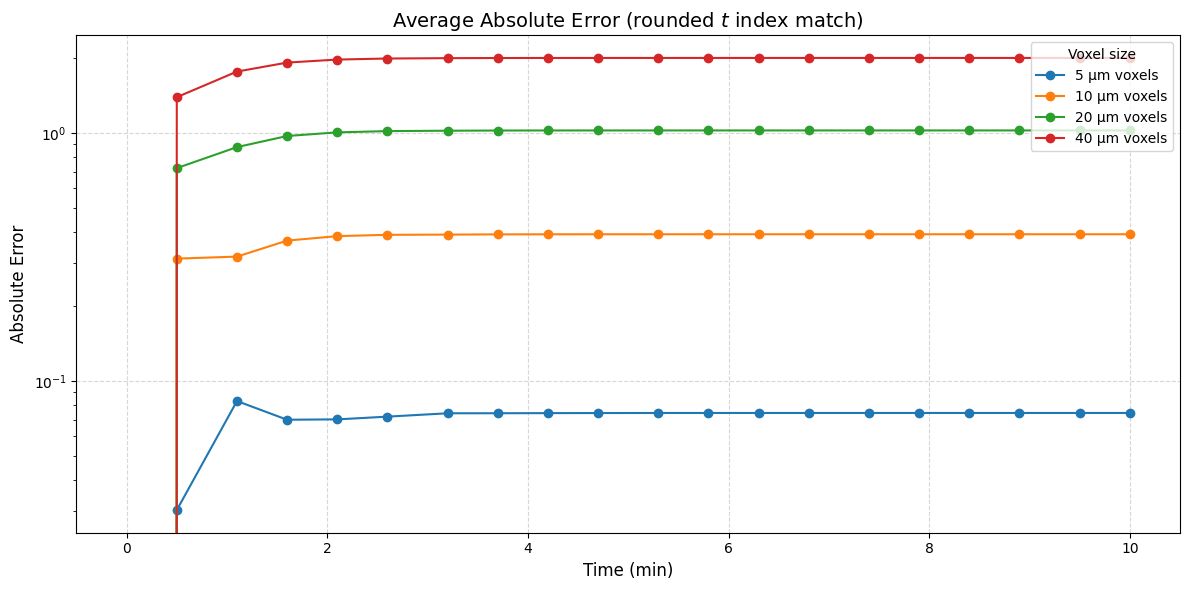

In [ ]:
# Average (whole box) error plots: two separate figures

# Analytical data as arrays (for interpolation)
dt_analytical_arr = np.asarray(dt_analytical, dtype=float)
dif_analytical_arr = np.asarray(dif_analytical, dtype=float)

# Analytical series on a rounded time grid (for exact index matching)
dt_analytical_rounded = np.round(dt_analytical_arr, 1)
analytical_series_rounded = (
    pd.Series(dif_analytical_arr, index=dt_analytical_rounded)
      .groupby(level=0).mean()
      .sort_index()
 )

# Figure 1: interpolated analytical-at-times error
fig_avg_interp, ax_avg_interp = plt.subplots(figsize=(12, 6))

# Figure 2: rounded-dt index-matched error
fig_avg_round, ax_avg_round = plt.subplots(figsize=(12, 6))

for folder in folders:
    frame = load_physicell_csv(folder)
    dh = float(frame['dx_um'].iloc[0])
    times = frame['time_min'].to_numpy(dtype=float)
    sim_series = pd.Series(frame['average_uM'].to_numpy(dtype=float), index=times)

    analytical_interp = np.interp(times, dt_analytical_arr, dif_analytical_arr)
    abs_error_interp = np.abs(sim_series.values - analytical_interp)

    sim_series_rounded = sim_series.copy()
    sim_series_rounded.index = np.round(sim_series_rounded.index.values.astype(float), 1)
    common_t = sim_series_rounded.index.intersection(analytical_series_rounded.index)
    abs_error_rounded = (
        sim_series_rounded.loc[common_t] - analytical_series_rounded.loc[common_t]
    ).abs()

    label = f"{int(dh)} μm voxels"
    pd.Series(abs_error_interp, index=times, name=label).plot(
        ax=ax_avg_interp, marker='o', linestyle='-', label=label
    )
    abs_error_rounded.rename(label).plot(
        ax=ax_avg_round, marker='o', linestyle='-', label=label
    )

ax_avg_interp.set_xlabel('Time (min)', fontsize=12)
ax_avg_interp.set_ylabel('Absolute Error', fontsize=12)
ax_avg_interp.set_title('Average Absolute Error (interpolated analytical)', fontsize=14)
ax_avg_interp.grid(True, linestyle='--', alpha=0.5)
ax_avg_interp.legend(title='Voxel size', loc='upper right')
ax_avg_interp.set_yscale('log')
fig_avg_interp.tight_layout()

ax_avg_round.set_xlabel('Time (min)', fontsize=12)
ax_avg_round.set_ylabel('Absolute Error', fontsize=12)
ax_avg_round.set_title('Average Absolute Error (rounded $t$ index match)', fontsize=14)
ax_avg_round.grid(True, linestyle='--', alpha=0.5)
ax_avg_round.legend(title='Voxel size', loc='upper right')
ax_avg_round.set_yscale('log')
fig_avg_round.tight_layout()

plt.show()

In [55]:
dt_analytical_center = [ 0.,0.52631579,1.05263158,1.57894737,2.10526316,2.63157895
,3.15789474,3.68421053,4.21052632,4.73684211,5.26315789,5.78947368
,6.31578947,6.84210526,7.36842105,7.89473684,8.42105263,8.94736842
,9.47368421,10.]
diff_analytical_center = [10.,5.93968034,3.94462468,3.18079231,2.91133497,2.81811149
,2.78600674,2.77496231,2.77116386,2.76985756,2.76940833,2.76925384
,2.76920071,2.76918244,2.76917616,2.76917399,2.76917325,2.769173
,2.76917291,2.76917288]

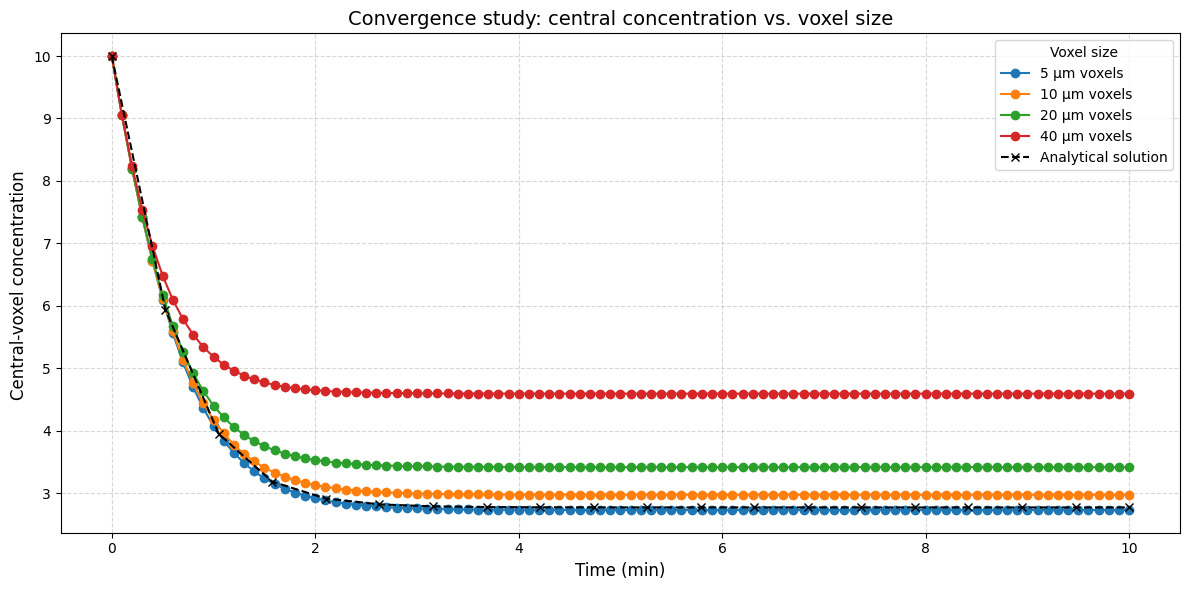

In [ ]:
# now plot the concentration on the central voxels

fig, ax = plt.subplots(figsize=(12, 6))
global_max = 0.0

for folder in folders:
    frame = load_physicell_csv(folder)
    dh = float(frame['dx_um'].iloc[0])
    times = frame['time_min'].to_numpy(dtype=float)
    center_vals = frame['center_uM'].to_numpy(dtype=float)

    label = f"{int(dh)} μm voxels"
    series = pd.Series(
        center_vals,
        index=pd.Index(times, name='Time (min)'),
        name=label,
    )
    series.plot(ax=ax, marker='o', linestyle='-')

    global_max = max(global_max, series.max())

ax.plot(dt_analytical_center, diff_analytical_center, label='Analytical solution', color='black', linestyle='--', marker='x')

ax.set_xlabel('Time (min)', fontsize=12)
ax.set_ylabel('Central-voxel concentration ', fontsize=12)
ax.set_title('Convergence study: central concentration vs. voxel size', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Voxel size', loc='upper right')

plt.tight_layout()
plt.show()

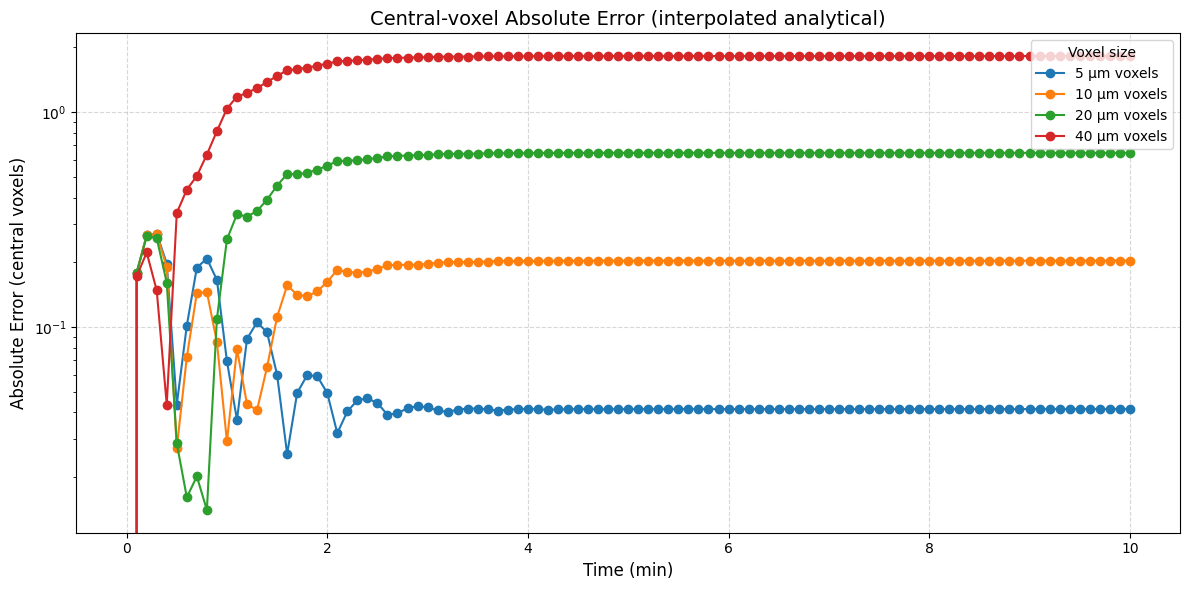

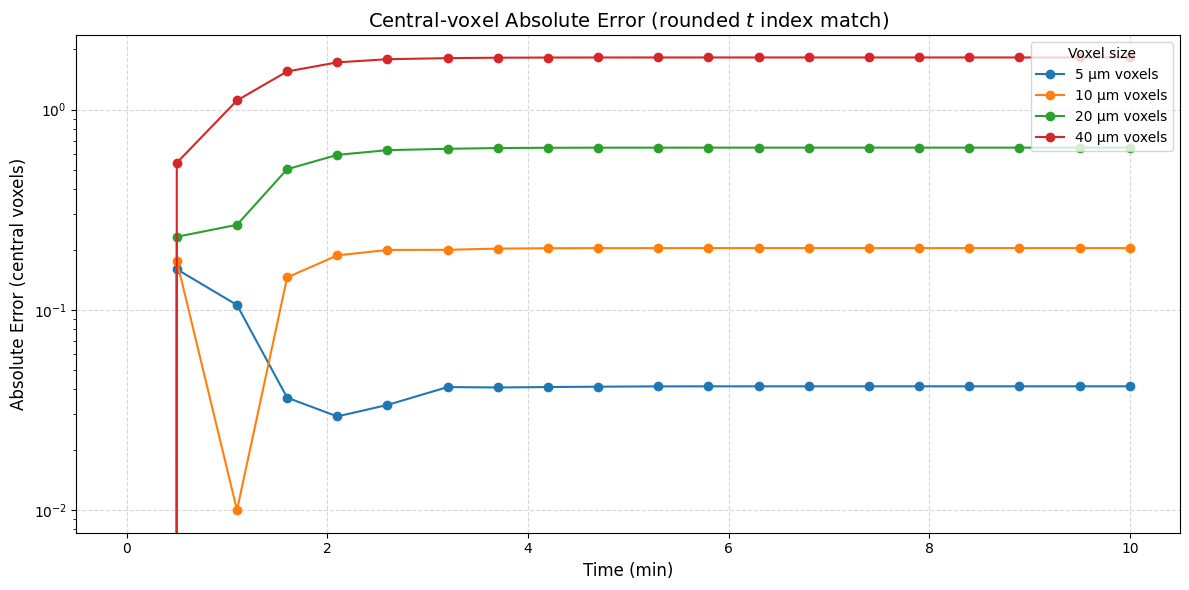

In [ ]:
# Central voxels error plots: two separate figures

# Analytical data as arrays (for interpolation)
dt_analytical_arr = np.asarray(dt_analytical_center, dtype=float)
dif_analytical_arr = np.asarray(diff_analytical_center, dtype=float)

# Analytical series on a rounded time grid (for exact index matching)
dt_analytical_rounded = np.round(dt_analytical_arr, 1)
analytical_series_rounded = (
    pd.Series(dif_analytical_arr, index=dt_analytical_rounded)
      .groupby(level=0).mean()
      .sort_index()
 )

# Figure 3: central interpolated analytical-at-times error
fig_center_interp, ax_center_interp = plt.subplots(figsize=(12, 6))

# Figure 4: central rounded-dt index-matched error
fig_center_round, ax_center_round = plt.subplots(figsize=(12, 6))

for folder in folders:
    frame = load_physicell_csv(folder)
    dh = float(frame['dx_um'].iloc[0])
    times = frame['time_min'].to_numpy(dtype=float)
    sim_series = pd.Series(frame['center_uM'].to_numpy(dtype=float), index=times)

    analytical_interp = np.interp(times, dt_analytical_arr, dif_analytical_arr)
    abs_error_interp = np.abs(sim_series.values - analytical_interp)

    sim_series_rounded = sim_series.copy()
    sim_series_rounded.index = np.round(sim_series_rounded.index.values.astype(float), 1)
    common_t = sim_series_rounded.index.intersection(analytical_series_rounded.index)
    abs_error_rounded = (
        sim_series_rounded.loc[common_t] - analytical_series_rounded.loc[common_t]
    ).abs()

    label = f"{int(dh)} μm voxels"
    pd.Series(abs_error_interp, index=times, name=label).plot(
        ax=ax_center_interp, marker='o', linestyle='-', label=label
    )
    abs_error_rounded.rename(label).plot(
        ax=ax_center_round, marker='o', linestyle='-', label=label
    )

ax_center_interp.set_xlabel('Time (min)', fontsize=12)
ax_center_interp.set_ylabel('Absolute Error (central voxels)', fontsize=12)
ax_center_interp.set_title('Central-voxel Absolute Error (interpolated analytical)', fontsize=14)
ax_center_interp.grid(True, linestyle='--', alpha=0.5)
ax_center_interp.legend(title='Voxel size', loc='upper right')
ax_center_interp.set_yscale('log')
fig_center_interp.tight_layout()

ax_center_round.set_xlabel('Time (min)', fontsize=12)
ax_center_round.set_ylabel('Absolute Error (central voxels)', fontsize=12)
ax_center_round.set_title('Central-voxel Absolute Error (rounded $t$ index match)', fontsize=14)
ax_center_round.grid(True, linestyle='--', alpha=0.5)
ax_center_round.legend(title='Voxel size', loc='upper right')
ax_center_round.set_yscale('log')
fig_center_round.tight_layout()

plt.show()